# 04 - LightGCN-HG: metadata-augmented variant (secondary)

The LightGCN paper (He et al., SIGIR 2020) learns embeddings by
symmetric-normalised propagation over the (user, item) bipartite graph.
Its standard form ignores everything about the hotel itself. **LightGCN-HG**
extends that graph with tier nodes parsed from the TripAdvisor hotel URL
so that hotels in the same place share representations even when they
have no co-reviewer.

This is kept as a *secondary* variant. The primary is SASRec (notebook 06).

## Design

Three tiers derived from `hotel_url`:

1. `g_id` - TripAdvisor's leaf-location id (one per city / neighbourhood).
2. `region_slug` - last 2 underscore tokens of the URL tail.
3. `country_slug` - last 1 token of the URL tail.

Each hotel adds one edge to each tier node. Tier nodes connect nowhere
else - they're pivot hubs for propagation. Symmetric normalisation
handles the resulting degree imbalance.

See `variants/hriday/PLAN.md` for the full design doc and the
decision trail that led from LightGCN-HG to SASRec as the primary variant.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp

def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for cand in [p, *p.parents]:
        if (cand / "src").is_dir() and (cand / "results").is_dir():
            return cand
    raise RuntimeError(f"Couldn't find repo root from {start}")

REPO = find_repo_root(Path.cwd())
DATA_DIR = REPO / "data" / "processed" / "20core"
META_DIR = REPO / "data" / "processed" / "hotel_meta"
HG_DIR   = REPO / "results" / "lightgcn_hg"

for p in [DATA_DIR, META_DIR]:
    assert p.exists(), f"Missing {p}"
print("Repo   :", REPO)
print("Data   :", DATA_DIR)
print("Meta   :", META_DIR)
print("HG out :", HG_DIR, "(exists:", HG_DIR.exists(), ")")

Repo   : C:\Datadrive\Hriday\Education\SJSU\2nd Sem\CMPE 256\Term Project\GitHub Repo
Data   : C:\Datadrive\Hriday\Education\SJSU\2nd Sem\CMPE 256\Term Project\GitHub Repo\data\processed\20core
Meta   : C:\Datadrive\Hriday\Education\SJSU\2nd Sem\CMPE 256\Term Project\GitHub Repo\data\processed\hotel_meta
HG out : C:\Datadrive\Hriday\Education\SJSU\2nd Sem\CMPE 256\Term Project\GitHub Repo\results\lightgcn_hg (exists: True )


## 1. Hotel-metadata extraction

`scripts/extract_hotel_meta.py` parses the 27,197 hotel URLs and produces
`data/processed/hotel_meta/hotel_meta.parquet`. It touches nothing under
`data/processed/20core/`, so teammates' variants remain unaffected.

URL shape:

    Hotel_Review-g{geo_id}-d{hotel_id}-Reviews-{name}-{location_slug}.html

Example: `Hotel_Review-g194775-d1121769-Reviews-Hotel_Baltic-Giulianova_Province_of_Teramo_Abruzzo.html`

- `g194775` -> TripAdvisor location id (used as the finest tier).
- `Hotel_Baltic` -> hotel name.
- `Giulianova_Province_of_Teramo_Abruzzo` -> location slug; last 2 tokens
  (`Teramo_Abruzzo`) become the region tier, last 1 (`Abruzzo`) becomes
  the country tier.


In [2]:
with open(META_DIR / "hotel_meta_stats.json") as f:
    meta_stats = json.load(f)
pd.Series(meta_stats).to_frame("value")

,value
n_hotels,27197
n_parse_failures,0
n_unique_g_id,7760
n_unique_region,3706
n_unique_country,787
g_id_singletons,4079
region_singletons,1589
country_singletons,299
max_hotels_per_g_id,343
max_hotels_per_region,561


In [3]:
meta = pd.read_parquet(META_DIR / "hotel_meta.parquet")
meta.head(5)

,item_id,hotel_url,g_id,hotel_name,location_slug,region_slug,country_slug
0,0,Hotel_Review-g10006284-d1083311-Reviews-The_Re...,10006284,The_Regent_Grand,Grace_Bay_Providenciales_Turks_and_Caicos,and_Caicos,Caicos
1,1,Hotel_Review-g10006284-d151184-Reviews-Club_Me...,10006284,Club_Med_Turkoise_Turks_Caicos,Grace_Bay_Providenciales_Turks_and_Caicos,and_Caicos,Caicos
2,2,Hotel_Review-g10006284-d151225-Reviews-Ports_o...,10006284,Ports_of_Call_Resort,Grace_Bay_Providenciales_Turks_and_Caicos,and_Caicos,Caicos
3,3,Hotel_Review-g10006284-d151307-Reviews-The_San...,10006284,The_Sands_at_Grace_Bay,Grace_Bay_Providenciales_Turks_and_Caicos,and_Caicos,Caicos
4,4,Hotel_Review-g10006284-d972924-Reviews-Seven_S...,10006284,Seven_Stars_Resort_Spa,Grace_Bay_Providenciales_Turks_and_Caicos,and_Caicos,Caicos


53 % of `g_id` locations are singletons (one hotel). That's the singleton
problem -- a location pivot only does work when it has at least two
hotels attached. Region (last-2 tokens) brings singletons down to 6 %;
country (last-1 token) to 1 %.


In [4]:
# Singleton breakdown per tier -- same numbers as the stats JSON but
# rederived here so the math is visible.
def singleton_pct(col):
    cnt = meta.groupby(col).size()
    return {
        "unique_values":    len(cnt),
        "singletons":       int((cnt == 1).sum()),
        "singleton_%":      round(100 * (cnt == 1).sum() / len(cnt), 2),
        "top_size":         int(cnt.max()),
        "top_value":        cnt.idxmax(),
    }

pd.DataFrame({c: singleton_pct(c) for c in ["g_id", "region_slug", "country_slug"]}).T

,unique_values,singletons,singleton_%,top_size,top_value
g_id,7760.0,4079.0,52.56,343.0,186338.0
region_slug,3706,1589,42.88,561,New_York
country_slug,787,299,37.99,2777,England


## 2. Graph construction (scipy-only)

Same layout as in `src/graph/hetero_adj.py` but re-run live here
so the node and edge counts are visibly derived. We construct the
symmetric-normalised adjacency `A_hat = D^{-1/2} A D^{-1/2}` directly in
scipy sparse -- no torch needed -- and show the node block offsets.


In [5]:
import sys
sys.path.insert(0, str(REPO))
from src.graph.hetero_adj import build_hg_norm_adj_scipy

# Inline loaders -- avoids importing src.data.dataset which pulls in torch
# (and can't load while the GPU training process holds the CUDA DLL).
ints = pd.read_parquet(DATA_DIR / "interactions.parquet")
n_users = int(ints["user_id"].max() + 1)
n_items = int(ints["item_id"].max() + 1)
train_df = pd.read_parquet(DATA_DIR / "train.parquet")
print(f"users: {n_users:,}, items: {n_items:,}, train rows: {len(train_df):,}")

rows = []
for tiers in [[], ["g_id"], ["g_id", "region_slug"], ["g_id", "region_slug", "country_slug"]]:
    hmeta = meta if tiers else pd.DataFrame(columns=["item_id"])
    A, gm = build_hg_norm_adj_scipy(
        train_df["user_id"].values.astype(np.int64),
        train_df["item_id"].values.astype(np.int64),
        hmeta, n_users, n_items, tiers=tiers,
    )
    rows.append({
        "tiers":          ", ".join(tiers) if tiers else "none (bipartite)",
        "n_user":         gm["n_users"],
        "n_item":         gm["n_items"],
        "n_g_id":         gm["tier_sizes"].get("g_id", 0),
        "n_region":       gm["tier_sizes"].get("region_slug", 0),
        "n_country":      gm["tier_sizes"].get("country_slug", 0),
        "n_total_nodes":  gm["n_total"],
        "n_edges_dir":    gm["n_edges_sym"],
        "A_hat_nnz":      A.nnz,
    })
graph_table = pd.DataFrame(rows)
graph_table

users: 46,660, items: 27,197, train rows: 1,479,659


,tiers,n_user,n_item,n_g_id,n_region,n_country,n_total_nodes,n_edges_dir,A_hat_nnz
0,none (bipartite),46660,27197,0,0,0,73857,2959318,2266392
1,g_id,46660,27197,7760,0,0,81617,3013712,2320786
2,"g_id, region_slug",46660,27197,7760,3706,0,85323,3068106,2375180
3,"g_id, region_slug, country_slug",46660,27197,7760,3706,787,86110,3122500,2429574


Interpretation: adding the full three-tier augmentation grows the graph
by 12,253 nodes (7,760 + 3,706 + 787 for g_id, region, country) and
163,182 directed edges (2 * 27,197 per tier). Everything else stays the
same -- the user-item block is untouched. This lets me re-use exactly
the same BPR loop (`src/train_lightgcn_hg.py`), just with a bigger
adjacency.

## 3. Degree distribution of tier nodes

High-degree nodes are down-weighted by symmetric normalisation
(`1 / sqrt(deg)`), but it's still worth checking that no single pivot is
so connected it dominates everything.


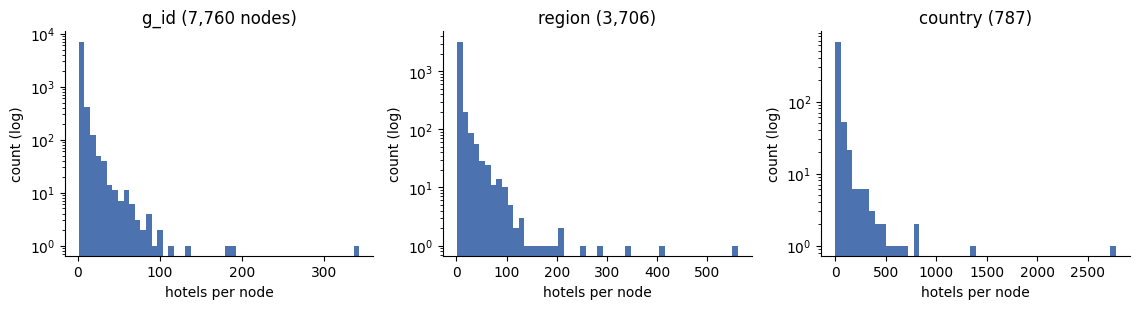

,g_id,region_slug,country_slug
min,1.0,1.00,1.00
median,1.0,2.00,3.00
mean,3.5,7.34,34.56
max,343.0,561.00,2777.00


In [6]:
import matplotlib.pyplot as plt

full_meta = meta.copy()
g_sizes       = full_meta.groupby("g_id").size()
region_sizes  = full_meta.groupby("region_slug").size()
country_sizes = full_meta.groupby("country_slug").size()

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.2))
for ax, series, title in zip(
    axes,
    [g_sizes, region_sizes, country_sizes],
    ["g_id (7,760 nodes)", "region (3,706)", "country (787)"],
):
    ax.hist(series.values, bins=50, color="#4c72b0")
    ax.set_yscale("log")
    ax.set_title(title)
    ax.set_xlabel("hotels per node"); ax.set_ylabel("count (log)")
    ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    "g_id":         [g_sizes.min(), g_sizes.median(), g_sizes.mean(), g_sizes.max()],
    "region_slug":  [region_sizes.min(), region_sizes.median(), region_sizes.mean(), region_sizes.max()],
    "country_slug": [country_sizes.min(), country_sizes.median(), country_sizes.mean(), country_sizes.max()],
}, index=["min", "median", "mean", "max"]).round(2)
summary

Country is the concerning one - the biggest country node attaches to
several hundred hotels. But with `1 / sqrt(n)` weighting each of those
contributions is scaled by ~ 0.05, so it should be absorbable.

## 4. Final test results

Loaded from `results/lightgcn_hg/test_metrics_L1_d256_grc.json`.


In [7]:
def load_if_exists(path: Path):
    if not path.exists():
        return None
    with open(path) as f:
        return json.load(f)

# Map short suffix -> (human label, tier list).
ABLATIONS = [
    ("none",  "LightGCN (vanilla, bipartite only)", []),
    ("grc",   "LightGCN-HG (g_id + region + country)",
     ["g_id", "region_slug", "country_slug"]),
]

rows = []
for suffix, label, tiers in ABLATIONS:
    m = load_if_exists(HG_DIR / f"test_metrics_L1_d256_{suffix}.json")
    if m is None:
        rows.append({"variant": label, "status": "not yet run", "tiers": ", ".join(tiers) or "none"})
        continue
    rows.append({
        "variant":     label,
        "status":      "done",
        "tiers":       ", ".join(tiers) or "none",
        "HR@5":        round(m["HR@5"], 4),
        "HR@10":       round(m["HR@10"], 4),
        "HR@20":       round(m["HR@20"], 4),
        "NDCG@5":      round(m["NDCG@5"], 4),
        "NDCG@10":     round(m["NDCG@10"], 4),
        "NDCG@20":     round(m["NDCG@20"], 4),
        "best_epoch":  m.get("best_epoch"),
        "total_nodes": m.get("n_total_nodes"),
        "time_s":      round(m.get("total_train_time_s", 0), 1),
    })
ablation_df = pd.DataFrame(rows)
ablation_df

,variant,status,tiers,HR@5,HR@10,HR@20,NDCG@5,NDCG@10,NDCG@20,best_epoch,total_nodes,time_s
0,"LightGCN (vanilla, bipartite only)",done,none,0.6414,0.7532,0.8612,0.5315,0.5677,0.5950,36,73857,2811.1
1,LightGCN-HG (g_id + region + country),done,"g_id, region_slug, country_slug",0.6460,0.7591,0.8655,0.5352,0.5718,0.5988,37,86110,3160.2


## 5. LightGCN-HG vs Phase-1 baselines


In [8]:
with open(REPO / "results" / "baselines" / "baseline_results_20core.json") as f:
    baselines = json.load(f)

done = [r for r in rows if r.get("status") == "done"]
if done:
    cols = ["HR@5", "HR@10", "HR@20", "NDCG@5", "NDCG@10", "NDCG@20"]
    rowset = {
        "Popularity": {c: round(baselines["Popularity"][c], 4) for c in cols},
        "ItemKNN":    {c: round(baselines["ItemKNN"][c], 4)    for c in cols},
        "GMF":        {c: round(baselines["GMF"][c], 4)        for c in cols},
    }
    for r in done:
        rowset[r["variant"]] = {c: r[c] for c in cols}
    pd.DataFrame(rowset).T
else:
    print("No HG results to compare yet. Re-run this notebook after training completes.")

In [9]:
# Deltas vs the strongest baseline on each metric.
if done:
    deltas = []
    for r in done:
        delta = {c: round(r[c] - max(baselines[b][c] for b in ("Popularity", "ItemKNN", "GMF")), 4)
                 for c in ["HR@5", "HR@10", "HR@20", "NDCG@5", "NDCG@10", "NDCG@20"]}
        deltas.append({"variant": r["variant"], **delta})
    pd.DataFrame(deltas).set_index("variant")
else:
    pass

## 6. Training curves


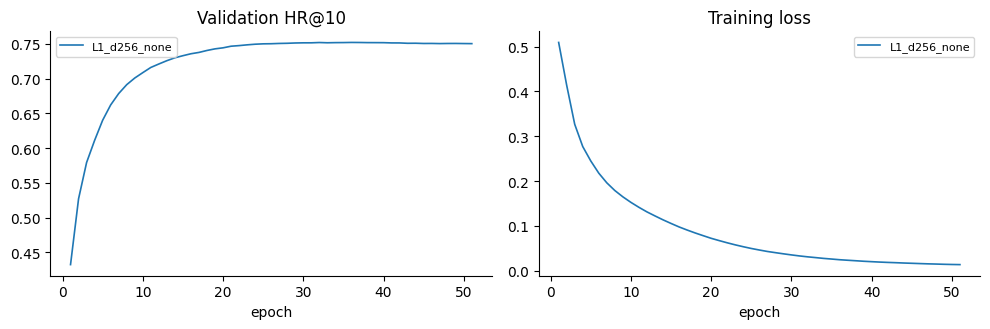

In [10]:
hg_logs = REPO / "logs" / "lightgcn_hg"
curves = {}
if hg_logs.exists():
    for csv in sorted(hg_logs.glob("metrics_*.csv")):
        curves[csv.stem.replace("metrics_", "")] = pd.read_csv(csv)
if curves:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    for name, df in curves.items():
        axes[0].plot(df["epoch"], df["HR@10"],      label=name, linewidth=1.2)
        axes[1].plot(df["epoch"], df["train_loss"], label=name, linewidth=1.2)
    axes[0].set_title("Validation HR@10"); axes[0].set_xlabel("epoch"); axes[0].legend(fontsize=8)
    axes[1].set_title("Training loss");    axes[1].set_xlabel("epoch"); axes[1].legend(fontsize=8)
    for ax in axes: ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout(); plt.show()
else:
    print("No HG training logs yet.")

## 7. What the graph change actually changes

With tier nodes, propagation step k updates each user/item embedding with
a weighted mean of its direct neighbours *and* tier-node "averages" of
its 1-hop co-located hotels. For a user who has reviewed one hotel in
Paris, at K = 1 the user's embedding pulls signal from:

- the Paris hotel directly
- through the Paris hotel, from the Paris `g_id` node (which averages
  every Paris hotel's embedding)
- through the Paris hotel, from the Ile-de-France `region_slug` node
  (average of every Ile-de-France hotel)
- through the Paris hotel, from the France `country_slug` node (average
  of every French hotel)

A bipartite-only LightGCN (the standard form from the paper) can only do
the first. The extra tier nodes are the structural change.

---

### Regenerate from scratch

```bash
# Metadata extraction (one-off, fast)
python -m scripts.extract_hotel_meta --kcore 20

# Three-tier training (~53 min on a single GPU)
python -m src.train_lightgcn_hg --config configs/lightgcn_hg.yaml --kcore 20
```
